## **Lorenz 96 Model Learned by SREINet with STLSQ Trainer**

## **I. Setup and Preprocessing**

In [35]:
# Import os library to access environment variables and operating system functionalities
import os

# Set environment variable to avoid duplicate library errors, specifically for OpenMP
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"
# Set TensorFlow log level to '2' to suppress most messages except warnings and errors
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'

import sys
sys.path.append("../utilities")

# Import necessary libraries for deep learning and numerical computation
import tensorflow as tf
import numpy as np
from SREINet import * 
import DataGenerator as DG


# Print a formatted message to the terminal to display current time, date, and TensorFlow version
print("**********************************************")
print("*                                            *")
print("*    Tensorflow Version: " + tf.__version__ + "              *")
print("*                                            *")
print("**********************************************")

from packaging import version
if version.parse(tf.__version__) < version.parse('2.10.0') and version.parse(tf.__version__) > version.parse('2.15.0'):
    print("Error: Tensorflow version is lower than 2.10.0 or higher than 2.15.0 Please use Tensorflow 2.10.0 - 2.15.0")
    sys.exit()

MY_DATA_TYPE = 'float32'
# Set the desired data type
tf.keras.backend.set_floatx(MY_DATA_TYPE)  

**********************************************
*                                            *
*    Tensorflow Version: 2.15.0              *
*                                            *
**********************************************


### **1.2 Training Data**

#### Create dataset

Guessed highest order polynomial: 2


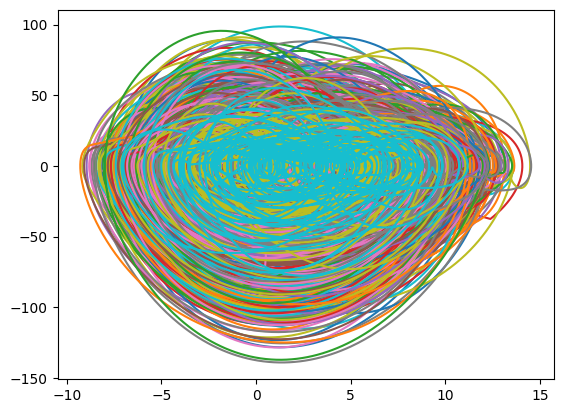

Training input shape: (60000, 100)
Training output shape: (60000, 100)


In [36]:
# Specify the model type
MY_MODEL = 'Lorenz_96' 
MY_DATA_TYPE = 'float32'

# Set the desired data type
tf.keras.backend.set_floatx(MY_DATA_TYPE)  

# Generate data based on the specified model type
LORENZ96_DIM = 100  #set up the dimension of the Lorenz 96 model

num_traj = 6
data_initial_conditions = DG.DataGenerator.generate_initial_conditions(LORENZ96_DIM, num_traj, seed=42) #np.random.normal(1, 2, LORENZ96_DIM

data_T =  10.0       # Length of the data (T)
data_dt = 0.001       # Resolution of the data (dt)
myDG = DG.DataGenerator(data_initial_conditions, T=data_T, dt=data_dt, derivative_mode="exact")
t_arr, x_train, dx_train, default_guessed_multiplicative_order = myDG.generate_dataset_by_model_name(MY_MODEL, method='DOP853')

print("Guessed highest order polynomial:", default_guessed_multiplicative_order)

#plot x_train and dx_train
import matplotlib.pyplot as plt
plt.plot(x_train, dx_train)
plt.show()

#Shuffle data
training_input, training_output = x_train, dx_train #data will be shuffled in the trainer


print("Training input shape:", training_input.shape)
print("Training output shape:", training_output.shape)

### **1.3 Hyperparameters**

In [37]:
# Set mini-batch size
MINI_BATCH_SIZE = 128
learning_rate = 0.001

### **1.4 Model Architecture Definitions**

**SREINet Parameters**

In [38]:
dim = training_input.shape[1] # the number of input state variables

# The grid size of each dimension
layer_depth = default_guessed_multiplicative_order
layer_neuron_nums_per_act_fn = [dim] * layer_depth
print(layer_neuron_nums_per_act_fn) # these numbers exclude the constant term

[100, 100]


## **II. Model and Training Preparation**

### **2.1 Create the SREINet Model**

In [39]:
my_activation = [lambda x:x]
inputs = tf.keras.layers.Input(shape=(dim,), dtype=MY_DATA_TYPE)
model = SREINet(layer_neuron_nums_per_act_fn,
                     activations=my_activation,
                     weight_initializer=tf.initializers.random_normal(stddev=0.001, seed=42),
                     data_type=MY_DATA_TYPE,
                     name='SREINet')
output = model(inputs)
model = tf.keras.Model(inputs=inputs, outputs=output)

### **2.2 Loss Function**

In [40]:
LOSS_FUNCTION = 'mse' #This can be 'MSE', 'LASSO', or 'RIDGE' or 'ElasticNet'(case insensitive)

from loss import *

# Example of selecting a loss function
loss_fn = myLoss(model, LOSS_FUNCTION) 

### **2.3 Optimizer**

In [41]:
my_optimizer = tf.keras.optimizers.Adam(learning_rate=learning_rate)  # Create an Adam optimizer with the defined learning rate

### **2.4 Trainer**

In [42]:
from stlsq_trainer import *

trainer = STLSQTrainer(model, my_optimizer, loss_fn, data_type='float32')

## **III.Training the Model**

#### **STLSQ Parameters**

In [46]:
# STLSQ training parameters
MAX_EPOCHS_PER_ITERATION = 50  # Maximum epochs per training iteration before pruning
MAX_ITERATIONS = 20  # Maximum number of prune-train iterations
PRUNING_THRESHOLD = 0.001  # Threshold for pruning weights
PLATEAU_WINDOW = 10  # Number of epochs to check for plateau
PLATEAU_THRESHOLD = 1e-8  # Threshold for relative loss change to be considered plateau
CONVERGENCE_THRESHOLD = 1e-10  # Threshold for convergence between iterations

### Training

In [47]:
# Setup
import time

training_histories = []
weights_list = []
loss_list = []

# Start timing
training_start_time = time.time()

In [48]:
for i in range(training_output.shape[1]):
    print(f"Training dimension {i + 1}...")
    
    output = training_output[:, i:i+1]
    
    history = trainer.fit(
        training_input, 
        output,
        batch_size=MINI_BATCH_SIZE, 
        validation_split=0.20,
        max_epochs_per_iteration=MAX_EPOCHS_PER_ITERATION,
        max_iterations=MAX_ITERATIONS,
        pruning_threshold=PRUNING_THRESHOLD,
        plateau_window=PLATEAU_WINDOW,
        plateau_threshold=PLATEAU_THRESHOLD,
        convergence_threshold=CONVERGENCE_THRESHOLD,
        verbose=2,
        print_every_n_epochs=10,
    )
    training_histories.append(history)

    # Retrieve the weights of the trained model
    weights_list.append([trainer.get_best_weights()])
    loss_list.append(trainer.get_best_loss())

    # Reset the model and trainer
    trainer.reset_trainer_and_model_weights(i)

# End timing
training_end_time = time.time()
total_training_time = training_end_time - training_start_time

print(f"\n{'='*60}")
print(f"Total Training Time: {total_training_time:.2f} seconds ({total_training_time/60:.2f} minutes)")
print(f"{'='*60}")

Training dimension 1...

STLSQ Iteration 1/20
  Epoch   1 (Global    1):  Train Loss: 8.792e+02,  Val Loss: 5.792e-01,  Time: 0.64s
  Epoch  11 (Global   11):  Train Loss: 7.431e+01,  Val Loss: 1.941e-01,  Time: 0.41s
  Epoch  21 (Global   21):  Train Loss: 5.824e+01,  Val Loss: 1.301e-01,  Time: 0.42s
  Epoch  31 (Global   31):  Train Loss: 1.407e-01,  Val Loss: 7.863e-02,  Time: 0.40s
  Epoch  41 (Global   41):  Train Loss: 1.328e-01,  Val Loss: 5.419e-02,  Time: 0.42s
  Epoch  50 (Global   50):  Train Loss: 9.340e-02,  Val Loss: 1.279e-01,  Time: 0.43s
  Iteration 1 complete: Min loss = 5.301491e-02
  Pruning: 10201 → 6175 nonzero weights (4026 pruned, 39.5% sparse)

STLSQ Iteration 2/20
  Epoch   1 (Global   51):  Train Loss: 9.072e-02,  Val Loss: 4.197e-02,  Time: 0.42s
  Epoch  11 (Global   61):  Train Loss: 8.095e-01,  Val Loss: 3.692e+00,  Time: 0.42s
  Epoch  21 (Global   71):  Train Loss: 1.177e-01,  Val Loss: 1.970e-01,  Time: 0.41s
  Epoch  31 (Global   81):  Train Loss: 1.

KeyboardInterrupt: 

## **IV. Coefficient Reconstructor**

#### `generate_set_labels`

The section below generates the layer labels that will be used to recontruct the symbolic of the right hand side (RHS) of governing equations. In addition, it also generates LHS labels.

In [12]:
def generate_layer_labels(N):
    return ['Constant'] + [f'x{i}' for i in range(1, N+1)]

def generate_LHS_labels(N):
    return [f"(x{i})'" for i in range(1, N+1)]

#### `coefficient_reconstruction`

In [13]:
from coefficient_reconstructor import *
cr = CoefficientReconstructor(generate_layer_labels, generate_LHS_labels)

## **V. Results**
### **Identified Model**

In [ ]:
weights_list

2

In [15]:
eq_str = []
for i in range(len(weights_list)):
    path_products = cr.reconstruct_coefficients(i,
                                               weights_list[i], 
                                            minimum_coefficient_threshold = 1e-3,
                                            coefficient_output_digits = 10, 
                                            enable_coefficient_sorting = False)
    
    for index, dimension in enumerate(path_products):
        print(f"{dimension}")
        eq_str.append(dimension)

(x1)' = 8 - 0.9999999404*x1 + x100*x2 - x100*x99


### **Validation**

In [ ]:
import model_reconstructor as mr

recovered_model = mr.RecoveredModel()
recovered_model.parse_ode_equations(eq_str);

### Comparing vector field

In [ ]:
pred_x_dot = recovered_model.predict_derivatives(x_train)

val_t_span = [0,data_T]
val_t_eval = np.arange(0,data_T,data_dt)

import matplotlib.pyplot as plt

plt.plot(val_t_eval, pred_x_dot[:val_t_eval.shape[0], 0],label='SREINet')
plt.plot(val_t_eval, dx_train[:val_t_eval.shape[0],0], '--', label='True')
plt.xlabel('Time')
plt.ylabel(r'$\dot{x}_1$')
plt.legend()
plt.show()

### Comparing response

In [ ]:
val_t_span = [0,data_T]
val_t_eval = np.arange(0,data_T,data_dt)

validation_result = recovered_model.simulate(data_initial_conditions[0], t_span=val_t_span,t_eval=val_t_eval, method='DOP853')

In [ ]:
import matplotlib.pyplot as plt

plt.plot(validation_result['t'], validation_result['y'][0],label='SREINet')
plt.plot(val_t_eval, x_train[:val_t_eval.shape[0],0], '--', label='True')
plt.xlabel('Time')
plt.ylabel('x1')
plt.legend()
plt.show()

In [ ]:
score =recovered_model.score(x_train[:val_t_eval.shape[0]], dx_train[:val_t_eval.shape[0]])
print(f"Score: {score}")

complexity = recovered_model.calculate_complexity()
print(f"Complexity: {complexity}")

complexity_per_dimension = complexity//dim
print(f"Complexity per dimension: {complexity_per_dimension}")

In [23]:
# Save hyperparameters
import pandas as pd

df = pd.DataFrame({
    'ODE model': [MY_MODEL],
    'Trainer': ['STLSQ'],
    'data initial conditions': [data_initial_conditions],
    'data length (T)': [data_T],
    'data resolution (dt)': [data_dt],
    'learning rate': [learning_rate],
    'layer depth': [layer_depth],
    'input dimension': [x_train.shape[1]],
    'mini_batch_size': [MINI_BATCH_SIZE],
    'Layer Neurons per activation fns': [layer_neuron_nums_per_act_fn],
    'Data Points': [training_input.shape[0]],
    'Max Epochs Per Iteration': [MAX_EPOCHS_PER_ITERATION],
    'Max Iterations': [MAX_ITERATIONS],
    'loss function': [LOSS_FUNCTION],
    'Best loss values': [str(loss_list)], 
    'pruning threshold': [PRUNING_THRESHOLD],
    'plateau window': [PLATEAU_WINDOW],
    'plateau threshold': [PLATEAU_THRESHOLD],
    'convergence threshold': [CONVERGENCE_THRESHOLD],
    'Total Training Time (seconds)': [total_training_time],
    'Total Training Time (minutes)': [total_training_time/60],
})

NameError: name 'total_training_time' is not defined

In [ ]:
# Save hyperparameters
import pandas as pd

df = pd.DataFrame({
    'ODE model': [MY_MODEL],
    'Trainer': ['STLSQ'],
    'data initial conditions': [data_initial_conditions],
    'data length (T)': [data_T],
    'data resolution (dt)': [data_dt],
    'learning rate': [learning_rate],
    'layer depth': [layer_depth],
    'input dimension': [x_train.shape[1]],
    'mini_batch_size': [MINI_BATCH_SIZE],
    'Layer Neurons per activation fns': [layer_neuron_nums_per_act_fn],
    'Data Points': [training_input.shape[0]],
    'Max Epochs Per Iteration': [MAX_EPOCHS_PER_ITERATION],
    'Max Iterations': [MAX_ITERATIONS],
    'loss function': [LOSS_FUNCTION],
    'Best loss values': [str(loss_list)], 
    'pruning threshold': [PRUNING_THRESHOLD],
    'plateau window': [PLATEAU_WINDOW],
    'plateau threshold': [PLATEAU_THRESHOLD],
    'convergence threshold': [CONVERGENCE_THRESHOLD],
})

In [ ]:
# Import the output helper module
import output_helper as opt_helper

# Save all results to Excel using the helper function
filepath = opt_helper.save_sreinet_results_to_excel(
    config_df=df,
    training_histories=training_histories,
    recovered_model=recovered_model,
    filename='lorenz96_stlsq_nn_configurations.xlsx',
    output_dir='output'
)